# Patch exploration

The goal is to find conditional and distributional correlations with amplitudes / colors distributions and labels.


## Requirements

In [1]:
import numpy as np
import deeplake
import os
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import random
from datetime import datetime
from tqdm import tqdm

LABEL_MAP = {
    "Stroma": 0,
    "Normal": 1,
    "G3":     2,
    "G4":     3,
    "G5":     4
}

REVERSE_LABEL_MAP = {0: "Stroma",
    1: "Normal", 
    2: "G3",
    3: "G4",
    4: "G5"
}

## Amplitude extractions

In [2]:
def Flat_log_Fourier(src_image, L=0.01):
    
    # Compute FFT of the source image
    fft_src = np.fft.fft2(src_image, axes=(-2, -1))
    amp_src = np.abs(fft_src)
    phase_src = np.angle(fft_src)

    # Shift amplitude spectra to center the low-frequency components
    amp_src = np.fft.fftshift(amp_src, axes=(-2, -1))

    # Defining the square of low amplitudes to be swapped
    _, height, width = amp_src.shape
    radius = int(np.floor(min(height, width) * L))
    center_h = height // 2
    center_w = width // 2

    h_start, h_end = center_h - radius, center_h + radius + 1
    w_start, w_end = center_w - radius, center_w + radius + 1

    small_amp = amp_src[:, h_start:h_end, w_start:w_end]

    return np.log(small_amp.reshape(-1))

dataset_path_akoya_1 = f"/home/leolr-int/nfs/data/data/patched/dim_256/Train/Subset3_Train_1_Akoya"
akoya_1 = deeplake.open_read_only(dataset_path_akoya_1)

# Preprocessing
src_img = akoya_1[200]["patch"].transpose((2, 0, 1)) 
print(Flat_log_Fourier(src_img))
print(len(Flat_log_Fourier(src_img)))

[10.72968828 10.87027149 10.32206744 11.36520953 11.94543284 11.85280867
 10.99149009 11.06714864  9.80301996 11.3958142  11.94771888 11.31831403
 16.43901608 11.31831403 11.94771888 11.3958142   9.80301996 11.06714864
 10.99149009 11.85280867 11.94543284 11.36520953 10.32206744 10.87027149
 10.72968828 10.23796142 11.28155811 10.79568398 11.70807848 12.0833677
 11.75780574 10.95748935 11.62618943 10.98913147 12.27952787 11.41043939
 10.36950676 16.07781091 10.36950676 11.41043939 12.27952787 10.98913147
 11.62618943 10.95748935 11.75780574 12.0833677  11.70807848 10.79568398
 11.28155811 10.23796142  8.01799344 10.16877095  9.08203862 10.9730164
 11.37710229 10.66138433 10.32184102 10.72468183 10.84279119 11.36165889
 10.75955693  9.99530605 16.42815754  9.99530605 10.75955693 11.36165889
 10.84279119 10.72468183 10.32184102 10.66138433 11.37710229 10.9730164
  9.08203862 10.16877095  8.01799344]
75


In [ ]:
# Creation of Train and Test datasets
# Akoya and Leica scanners considered
# specify 'group' (WSI) to avoid data leakage!

'''def load_data(input_root, train_or_test, L=0.01):
    
    X, y, groups = [], [], []
    for scanner in ['Akoya', 'Leica']:
        for i in range(1,26+1):
            dataset_name = f"Subset3_{train_or_test}_{i}_{scanner}"
            dataset_path = f"{input_root}/{train_or_test}/{dataset_name}"
            if not os.path.exists(dataset_path):
                continue
            
            print(f"Loading {dataset_path}")
            dataset = deeplake.open_read_only(dataset_path)

            for j in tqdm(range(len(dataset))):
                sample=dataset[j]
                if sample["patch"].shape != (256, 256, 3):
                    continue
                img = sample["patch"].transpose(2, 0, 1)
                label = int(sample["label"])
                feature = Flat_log_Fourier(img, L)
                X.append(feature)
                y.append(label)
                groups.append(dataset_name)
    return np.array(X), np.array(y), np.array(groups)'''

import os
from tqdm import tqdm
import numpy as np
from concurrent.futures import ProcessPoolExecutor
import deeplake

def _process_fourier(img_L):
    """Helper pour le multiprocessing."""
    img, L = img_L
    return Flat_log_Fourier(img, L)

def extract_features_parallel(imgs, L, max_workers=4):
    """Extrait les features en parallèle pour une liste d’images."""
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        return list(executor.map(_process_fourier, [(img, L) for img in imgs]))

def load_data(input_root, train_or_test, L=0.01, max_workers=4, binary=False):
    X, y, groups = [], [], []

    for scanner in ['Akoya', 'Leica']:
        for i in range(1, 27):  
            dataset_name = f"Subset3_{train_or_test}_{i}_{scanner}"
            dataset_path = f"{input_root}/{train_or_test}/{dataset_name}"
            if not os.path.exists(dataset_path):
                continue

            print(f"Loading {dataset_path}")
            dataset = deeplake.open_read_only(dataset_path)

            imgs, labels, group_list = [], [], []

            for sample in tqdm(dataset, desc=dataset_name):
                patch = sample["patch"]
                if patch.shape != (256, 256, 3):
                    continue

                img = patch.transpose(2, 0, 1)
                label = int(sample["label"]) #modify here for binary classification

                imgs.append(img)
                labels.append(label)
                group_list.append(dataset_name)

            if imgs:
                features = extract_features_parallel(imgs, L, max_workers=4)
                X.extend(features)
                y.extend(labels)
                groups.extend(group_list)

    return np.array(X), np.array(y), np.array(groups)




In [4]:
input_root = '/home/leolr-int/nfs/data/data/patched/dim_256'
X_train, y_train, groups_train = load_data(input_root, 'Train', L=0.01)

Loading /home/leolr-int/nfs/data/data/patched/dim_256/Train/Subset3_Train_1_Akoya


Subset3_Train_1_Akoya: 100%|██████████| 10675/10675 [00:20<00:00, 513.55it/s]
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/deeplake/__init__.py:322: UserWarning: Global variable 'akoya_1' of type <class 'deeplake._deeplake.ReadOnlyDataset'> may cause issues when using fork-based multiprocessing. Consider avoiding global variables of this type, or pass to subprocess as an agrument or by manual pickling.
  warnings.warn(
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/deeplake/__init__.py:322: UserWarning: Global variable 'akoya_1' of type <class 'deeplake._deeplake.ReadOnlyDataset'> may cause issues when using fork-based multiprocessing. Consider avoiding global variables of this type, or pass to subprocess as an agrument or by manual pickling.
  warnings.warn(


Loading /home/leolr-int/nfs/data/data/patched/dim_256/Train/Subset3_Train_2_Akoya


Subset3_Train_2_Akoya: 100%|██████████| 11743/11743 [00:23<00:00, 493.80it/s]


Loading /home/leolr-int/nfs/data/data/patched/dim_256/Train/Subset3_Train_3_Akoya


...

Subset3_Train_22_Leica: 100%|██████████| 8538/8538 [00:26<00:00, 324.56it/s]


Loading /home/leolr-int/nfs/data/data/patched/dim_256/Train/Subset3_Train_25_Leica


Subset3_Train_25_Leica: 100%|██████████| 8750/8750 [00:25<00:00, 349.21it/s]


Loading /home/leolr-int/nfs/data/data/patched/dim_256/Train/Subset3_Train_26_Leica


Subset3_Train_26_Leica: 100%|██████████| 13439/13439 [00:42<00:00, 317.10it/s]


In [5]:
X_test, y_test, groups_test = load_data(input_root, 'Test', L=0.01)

Loading /home/leolr-int/nfs/data/data/patched/dim_256/Test/Subset3_Test_1_Akoya


Subset3_Test_1_Akoya: 100%|██████████| 10202/10202 [00:31<00:00, 328.69it/s]


Loading /home/leolr-int/nfs/data/data/patched/dim_256/Test/Subset3_Test_2_Akoya


Subset3_Test_2_Akoya: 100%|██████████| 9088/9088 [00:27<00:00, 330.66it/s]


Loading /home/leolr-int/nfs/data/data/patched/dim_256/Test/Subset3_Test_3_Akoya


...

Subset3_Test_10_Leica: 100%|██████████| 1513/1513 [00:04<00:00, 363.60it/s]


Loading /home/leolr-int/nfs/data/data/patched/dim_256/Test/Subset3_Test_11_Leica


Subset3_Test_11_Leica: 100%|██████████| 5107/5107 [00:15<00:00, 337.26it/s]


Loading /home/leolr-int/nfs/data/data/patched/dim_256/Test/Subset3_Test_12_Leica


Subset3_Test_12_Leica: 100%|██████████| 6908/6908 [00:21<00:00, 317.71it/s]


## Conditional: find the best algorithm to guess the label from the log low amplitudes

### Train SGD Classifier


In [6]:
# Cross-validation

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pipeline = make_pipeline(
    StandardScaler(),
    SGDClassifier(
        class_weight = 'balanced',
        max_iter = 10000,
        early_stopping = False,
        n_iter_no_change = 10,
        n_jobs = 3,
        random_state = 42
    )
)

param_grid = {
    'sgdclassifier__loss': ['squared_hinge', 'log_loss'],
    'sgdclassifier__penalty': ['l2', 'elasticnet', None],
    'sgdclassifier__alpha': [1e-4, 1e-3, 1e-2]
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

search_sgdc = GridSearchCV(
    pipeline,
    param_grid,
    scoring='balanced_accuracy',
    cv=cv.split(X_train, y_train, groups=groups_train),
    n_jobs=-1,
    verbose=1
)





In [7]:
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

search_sgdc.fit(X_train, y_train)
print('Best CV balanced accuracy score:', search_sgdc.best_score_)
print('Best parameters:', search_sgdc.best_params_)



Fitting 5 folds for each of 18 candidates, totalling 90 fits


/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/deeplake/__init__.py:322: UserWarning: Global variable 'akoya_1' of type <class 'deeplake._deeplake.ReadOnlyDataset'> may cause issues when using fork-based multiprocessing. Consider avoiding global variables of this type, or pass to subprocess as an agrument or by manual pickling.
  warnings.warn(
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.war

Best CV balanced accuracy score: 0.4519439524622581
Best parameters: {'sgdclassifier__alpha': 0.01, 'sgdclassifier__loss': 'log_loss', 'sgdclassifier__penalty': 'elasticnet'}


Balanced accuracy on test: 0.4169846757628652
Classification report:
               precision    recall  f1-score   support

      Stroma       0.54      0.85      0.66     28604
      Normal       0.19      0.34      0.24     12297
          G3       0.51      0.27      0.35     43054
          G4       0.71      0.60      0.65     81085
          G5       0.00      0.03      0.00       514

    accuracy                           0.53    165554
   macro avg       0.39      0.42      0.38    165554
weighted avg       0.59      0.53      0.54    165554



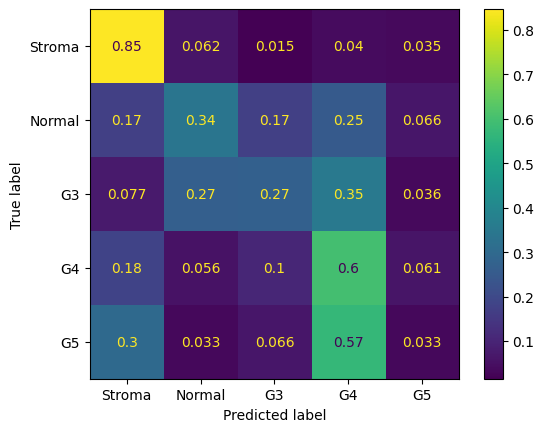

In [8]:
y_pred = search_sgdc.predict(X_test)
print('Balanced accuracy on test:', balanced_accuracy_score(y_test, y_pred))
print('Classification report:\n', classification_report(y_test, y_pred, target_names=LABEL_MAP.keys()))

from sklearn.metrics import ConfusionMatrixDisplay
_ = ConfusionMatrixDisplay.from_estimator(search_sgdc, X_test, y_test, display_labels=LABEL_MAP, normalize='true')
#normalised over true labels (over rows)


## Random forest 

(no online-learning but can capture more complex relations)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#scale doesnt matter here so we have the possibility not to include the scaler
pipeline = make_pipeline(
    RandomForestClassifier(
        class_weight='balanced',
        n_jobs = -1,
        random_state = 42,
    )
)

param_grid = {
    'randomforestclassifier__n_estimators':[50,100],
    'randomforestclassifier__max_depth': [None, 10, 20],
    'randomforestclassifier__max_features': [None, 'sqrt']
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
#group
search_rf = GridSearchCV(
    pipeline,
    param_grid,
    scoring='balanced_accuracy',
    cv=cv.split(X_train, y_train, groups=groups_train),
    n_jobs=3,
    verbose=1
)

In [12]:
search_rf.fit(X_train, y_train)
print('Best CV balanced accuracy score:', search_rf.best_score_)
print('Best parameters:', search_rf.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/deeplake/__init__.py:322: UserWarning: Global variable 'akoya_1' of type <class 'deeplake._deeplake.ReadOnlyDataset'> may cause issues when using fork-based multiprocessing. Consider avoiding global variables of this type, or pass to subprocess as an agrument or by manual pickling.
  warnings.warn(
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
Exception ignored in: <function ResourceTracker.__del__ at 0x7e0f9dfaade0>
Traceback (most recent call last):
  File "/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/leolr-int/micromamba/envs/py3

Best CV balanced accuracy score: 0.4651531038744265
Best parameters: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 100}


Balanced accuracy on test: 0.41463731579154206
Classification report:
               precision    recall  f1-score   support

      Stroma       0.50      0.75      0.60     28604
      Normal       0.21      0.44      0.28     12297
          G3       0.38      0.49      0.43     43054
          G4       0.74      0.23      0.35     81085
          G5       0.01      0.16      0.01       514

    accuracy                           0.41    165554
   macro avg       0.37      0.41      0.34    165554
weighted avg       0.56      0.41      0.41    165554



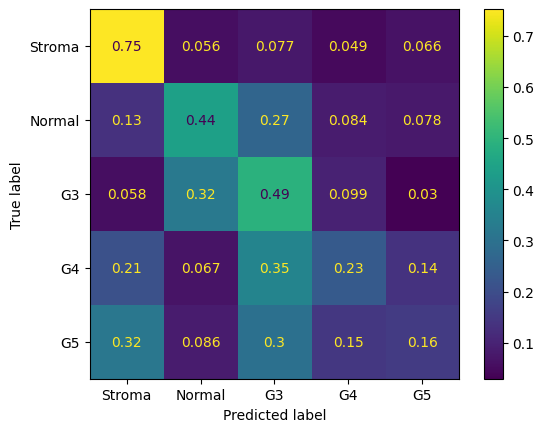

In [13]:
y_pred = search_rf.predict(X_test)
print('Balanced accuracy on test:', balanced_accuracy_score(y_test, y_pred))
print('Classification report:\n', classification_report(y_test, y_pred, target_names=LABEL_MAP.keys()))

from sklearn.metrics import ConfusionMatrixDisplay
_ = ConfusionMatrixDisplay.from_estimator(search_rf, X_test, y_test, display_labels=LABEL_MAP, normalize='true')
#normalised over true labels (over rows)

### Test on KFBio



In [ ]:
def load_KFBio(input_root, train_or_test, L=0.01, max_workers=4):
    X, y, groups = [], [], []

    for scanner in ['KFBio']:
        for i in range(1, 27):  
            dataset_name = f"Subset3_{train_or_test}_{i}_{scanner}"
            dataset_path = f"{input_root}/{train_or_test}/{dataset_name}"
            if not os.path.exists(dataset_path):
                continue

            print(f"Loading {dataset_path}")
            dataset = deeplake.open_read_only(dataset_path)

            imgs, labels, group_list = [], [], []

            for sample in tqdm(dataset, desc=dataset_name):
                patch = sample["patch"]
                if patch.shape != (256, 256, 3):
                    continue

                img = patch.transpose(2, 0, 1)
                label = int(sample["label"])

                imgs.append(img)
                labels.append(label)
                group_list.append(dataset_name)

            if imgs:
                features = extract_features_parallel(imgs, L, max_workers=4)
                X.extend(features)
                y.extend(labels)
                groups.extend(group_list)

    return np.array(X), np.array(y), np.array(groups)

X_test_KFbio, y_test_KFbio, groups_test_KFbio = load_KFBio(input_root, 'Test', L=0.01)



Loading /home/leolr-int/nfs/data/data/patched/dim_256/Test/Subset3_Test_1_KFBio


Subset3_Test_1_KFBio: 100%|██████████| 11126/11126 [01:13<00:00, 151.40it/s]
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/deeplake/__init__.py:322: UserWarning: Global variable 'akoya_1' of type <class 'deeplake._deeplake.ReadOnlyDataset'> may cause issues when using fork-based multiprocessing. Consider avoiding global variables of this type, or pass to subprocess as an agrument or by manual pickling.
  warnings.warn(
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/deeplake/__init__.py:322: UserWarning: Global variable 'akoya_1' of type <class 'deeplake._deeplake.ReadOnlyDataset'> may cause issues when using fork-based multiprocessing. Consider avoiding global variables of this type, or pass to subprocess as an agrument or by manual pickling.
  warnings.warn(


Loading /home/leolr-int/nfs/data/data/patched/dim_256/Test/Subset3_Test_2_KFBio


Subset3_Test_2_KFBio: 100%|██████████| 9857/9857 [01:27<00:00, 112.45it/s]


Loading /home/leolr-int/nfs/data/data/patched/dim_256/Test/Subset3_Test_3_KFBio


...

Loading /home/leolr-int/nfs/data/data/patched/dim_256/Test/Subset3_Test_11_KFBio


Subset3_Test_11_KFBio: 100%|██████████| 6130/6130 [00:51<00:00, 118.09it/s]


Loading /home/leolr-int/nfs/data/data/patched/dim_256/Test/Subset3_Test_12_KFBio


Subset3_Test_12_KFBio: 100%|██████████| 8352/8352 [01:15<00:00, 110.30it/s]


NameError: name 'search_sgcd' is not defined

Balanced accuracy on test: 0.24060792349983257
Classification report:
               precision    recall  f1-score   support

      Stroma       0.88      0.09      0.17     16388
      Normal       0.22      0.05      0.09      7101
          G3       0.43      0.06      0.11     24634
          G4       0.61      0.43      0.50     46413
          G5       0.00      0.57      0.01       293

    accuracy                           0.25     94829
   macro avg       0.43      0.24      0.17     94829
weighted avg       0.58      0.25      0.31     94829

Balanced accuracy on test: 0.26561432009510677
Classification report:
               precision    recall  f1-score   support

      Stroma       0.65      0.02      0.03     16388
      Normal       0.16      0.34      0.22      7101
          G3       0.15      0.05      0.07     24634
          G4       0.54      0.78      0.64     46413
          G5       0.01      0.14      0.02       293

    accuracy                           0.42

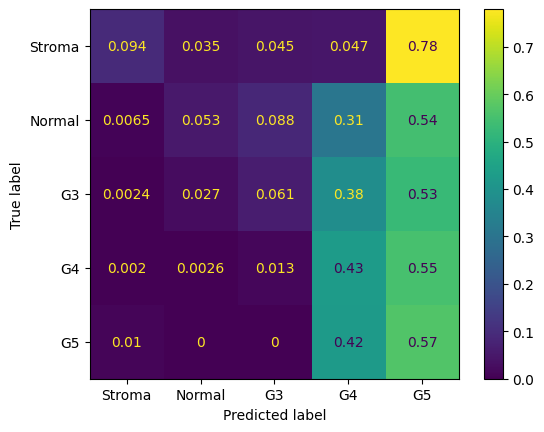

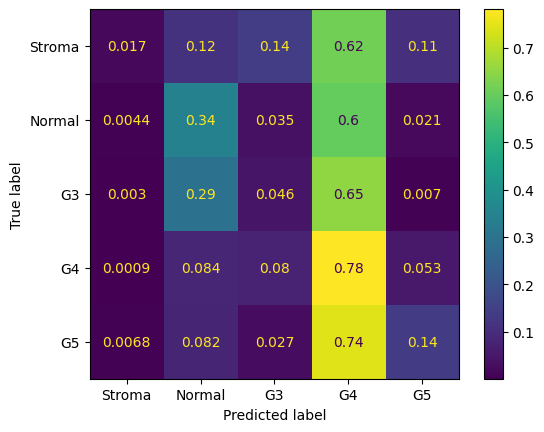

In [16]:
#SGD Classifier
y_pred_sgdc_KFbio = search_sgdc.predict(X_test_KFbio)
print('Balanced accuracy on test:', balanced_accuracy_score(y_test_KFbio, y_pred_sgdc_KFbio))
print('Classification report:\n', classification_report(y_test_KFbio, y_pred_sgdc_KFbio, target_names=LABEL_MAP.keys()))

from sklearn.metrics import ConfusionMatrixDisplay
_ = ConfusionMatrixDisplay.from_estimator(search_sgdc, X_test_KFbio, y_test_KFbio, display_labels=LABEL_MAP, normalize='true')
#normalised over true labels (over rows)

#Random Forest
y_pred_rf_KFbio = search_rf.predict(X_test_KFbio)
print('Balanced accuracy on test:', balanced_accuracy_score(y_test_KFbio, y_pred_rf_KFbio))
print('Classification report:\n', classification_report(y_test_KFbio, y_pred_rf_KFbio, target_names=LABEL_MAP.keys()))

from sklearn.metrics import ConfusionMatrixDisplay
_ = ConfusionMatrixDisplay.from_estimator(search_rf, X_test_KFbio, y_test_KFbio, display_labels=LABEL_MAP, normalize='true')
#normalised over true labels (over rows)

### Downloading the chosen model

## Distributional 

In [ ]:
# non binary distributions per coordinate

from scipy.stats import gaussian_kde


def compute_smoothed_cdfs(X_train, y_train, num_points=512):
    labels = np.unique(y_train)
    n_features = X_train.shape[1]
    cdf_dict = {}

    for label in tqdm(labels, desc="Processing labels"):
        X_label = X_train[y_train == label]
        cdf_dict[label] = {}

        for feature_idx in range(n_features):
            values = X_label[:, feature_idx]

            # Fit KDE
            kde = gaussian_kde(values)

            # Evaluate KDE on linspace covering the data range
            xmin, xmax = np.percentile(values, [0.5, 99.5])  # robust range
            xs = np.linspace(xmin, xmax, num_points)
            pdf = kde(xs)

            # Normalize to CDF
            cdf = np.cumsum(pdf)
            cdf /= cdf[-1]  # Normalize to [0,1]

            cdf_dict[label][feature_idx] = (xs, cdf)

    return cdf_dict

In [ ]:
cdf_per_class_and_feature = compute_smoothed_cdfs(X_train, y_train)

## Optimal Transport on colors

Consider two 3D-distributions: for Stroma/Normal and G3/G4/G5. 
--> how to base this distribution? Average of the three channels per patch?

Be simple: just consider the distribution of average colors per channel per binary class. 